# Metro Interstate Traffic Volume — Predictive Models Analysis
**Course:** Modelos Predictivos — Parcial I  
**Dataset:** Metro Interstate Traffic Volume (`Metro_Interstate_Traffic_Volume.csv`)  
**Task:** Regression — predict `traffic_volume` (vehicles/hour)  
**Author:** Sergio Florez  
---

## Notebook Index
1. Dataset Description  
   1.1 Context and Objective  
   1.2 Feature Descriptions  
2. Data Loading & Global Cleaning  
   2.1 Load Data  
   2.2 Quality Check  
   2.3 Deduplication  
   2.4 Datetime Parsing  
   2.5 Zero Traffic Investigation  
   2.6 Holiday Encoding  
3. Train/Test Split  
   3.1 Split Configuration  
   3.2 Split Verification  
4. Exploratory Data Analysis (Training Set Only)  
   4.1 How does traffic vary by hour and day type?  
   4.2 What is the distribution of traffic_volume and are there anomalies?  
   4.3 Does weather have a detectable effect on traffic?  
5. Feature Engineering & Selection  
   5.1 Temporal Features (confirm)  
   5.2 Weather Description Cardinality Reduction  
   5.3 ColumnTransformer Pipeline  
   5.4 Note on `year` Feature  
6. Model Training & Cross-Validation  
   6.1 Baseline — DummyRegressor  
   6.2 Model 1 — Linear Regression  
   6.3 Model 2 — Gradient Boosting Regressor  
   6.4 CV Comparison Table  
7. Final Evaluation on Test Set  
   7.1 Metrics Table  
   7.2 Diagnostic Plots  
   7.3 CV vs. Test Comparison  
8. Conclusions

In [ ]:
!pip install -q imbalanced-learn xgboost

In [ ]:
# ── Standard library ────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

# ── Data manipulation ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Sklearn — data splitting & CV ────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
)

# ── Sklearn — preprocessing & pipelines ─────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── Sklearn — models ─────────────────────────────────────────────────────────
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# ── Sklearn — metrics ────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

## Project Constants

In [ ]:
# ── Reproducibility & split configuration ────────────────────────────────────
RANDOM_STATE  = 123
TEST_SIZE     = 0.2

# ── Dataset path ─────────────────────────────────────────────────────────────
DATA_PATH     = "/content/Metro_Interstate_Traffic_Volume.csv"

# ── Target column ─────────────────────────────────────────────────────────────
TARGET_COL    = "traffic_volume"

# ── Cardinality threshold for weather_description grouping ───────────────────
RARE_CAT_THRESH = 0.01      # Categories representing < 1% of rows → "Other"

# ── CV configuration ──────────────────────────────────────────────────────────
N_FOLDS       = 5

# ── Plot output folder ────────────────────────────────────────────────────────
FIG_DIR       = "/content/figures_traffic"
os.makedirs(FIG_DIR, exist_ok=True)

print("Constants defined ✅")
print(f"  RANDOM_STATE    : {RANDOM_STATE}")
print(f"  TEST_SIZE       : {TEST_SIZE}")
print(f"  RARE_CAT_THRESH : {RARE_CAT_THRESH}")
print(f"  N_FOLDS         : {N_FOLDS}")
print(f"  FIG_DIR         : {FIG_DIR}")

Constants defined ✅
  RANDOM_STATE    : 123
  TEST_SIZE       : 0.2
  RARE_CAT_THRESH : 0.01
  N_FOLDS         : 5
  FIG_DIR         : /content/figures_traffic


## Environment Verification
**Expected shape:** (~48,204 rows, 9 columns) — shape may vary slightly depending on the source file version.

In [ ]:
try:
    _df_check = pd.read_csv(DATA_PATH)
    print(f"File loaded successfully ✅")
    print(f"  Shape   : {_df_check.shape}")
    print(f"  Columns : {list(_df_check.columns)}")

    expected_cols = 9
    if _df_check.shape[1] != expected_cols:
        print(f"\n⚠️  Expected {expected_cols} columns, got {_df_check.shape[1]}. Verify the file.")
    else:
        print(f"\nColumn count matches expected {expected_cols} ✅")

    assert TARGET_COL in _df_check.columns, f"Target column '{TARGET_COL}' not found!"
    print(f"Target column '{TARGET_COL}' present ✅")

except FileNotFoundError:
    print(f"❌ File not found at: {DATA_PATH}")
    print("   → Go to Colab sidebar > Files > Upload, then re-run this cell.")

File loaded successfully ✅
  Shape   : (48204, 9)
  Columns : ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']

Column count matches expected 9 ✅
Target column 'traffic_volume' present ✅


---
## 2. Data Loading & Global Cleaning
---

### 2.1 Load Data

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"  {i:2d}: '{col}'")

Shape: (48204, 9)

Column names:
   0: 'holiday'
   1: 'temp'
   2: 'rain_1h'
   3: 'snow_1h'
   4: 'clouds_all'
   5: 'weather_main'
   6: 'weather_description'
   7: 'date_time'
   8: 'traffic_volume'


### 2.2 Quality Check

Inspect data types, missing values, and a statistical summary.  
No transformations yet — only observation and documentation.

In [ ]:
# ── Data types ───────────────────────────────────────────────────────────────
print("=== Data Types ===")
print(df.dtypes)
print()

# ── Missing values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✅")
print()

# ── Statistical summary ───────────────────────────────────────────────────────
print("=== Statistical Summary (numeric columns) ===")
print(df.describe().round(2).to_string())

=== Data Types ===
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

=== Missing Values ===
holiday    48143
dtype: int64

=== Statistical Summary (numeric columns) ===
           temp   rain_1h   snow_1h  clouds_all  traffic_volume
count  48204.00  48204.00  48204.00    48204.00        48204.00
mean     281.21      0.33      0.00       49.36         3259.82
std       13.34     44.79      0.01       39.02         1986.86
min        0.00      0.00      0.00        0.00            0.00
25%      272.16      0.00      0.00        1.00         1193.00
50%      282.45      0.00      0.00       64.00         3380.00
75%      291.81      0.00      0.00       90.00         4933.00
max      310.07   9831.30      0.51      100.00         7280.00


### 2.3 Investigate `holiday` missing values

The quality check shows 48,143 apparent missing values in `holiday`.  
This is suspicious — it likely means most rows contain the string `"None"` which pandas reads as `NaN`.  
We inspect the raw unique values before deciding how to handle it.


In [ ]:
# ── Check raw value counts including NaN ─────────────────────────────────────
print("=== Holiday column — raw value counts ===")
print(df["holiday"].value_counts(dropna=False).to_string())
print()
print(f"Total rows        : {len(df)}")
print(f"NaN count         : {df['holiday'].isna().sum()}")
print(f"Non-NaN count     : {df['holiday'].notna().sum()}")

=== Holiday column — raw value counts ===
holiday
NaN                          48143
Labor Day                        7
Christmas Day                    6
Thanksgiving Day                 6
Martin Luther King Jr Day        6
New Years Day                    6
Veterans Day                     5
Columbus Day                     5
Memorial Day                     5
Washingtons Birthday             5
State Fair                       5
Independence Day                 5

Total rows        : 48204
NaN count         : 48143
Non-NaN count     : 61


### 2.4 Cleaning Steps

#### 2.4.1 — Encode `holiday` to binary `is_holiday`

`NaN` means no holiday (0). Any named holiday maps to 1.  
The original `holiday` column is dropped after encoding.  
This is a factual mapping — not a statistical transformation.

In [ ]:
df["is_holiday"] = df["holiday"].notna().astype(int)

print("=== is_holiday distribution ===")
print(df["is_holiday"].value_counts().sort_index())
print()
print(f"Holiday rows     : {df['is_holiday'].sum():,} ({df['is_holiday'].mean():.2%})")
print(f"Non-holiday rows : {(df['is_holiday'] == 0).sum():,}")

df = df.drop(columns=["holiday"])
print(f"\n✅ 'holiday' dropped. 'is_holiday' binary column created.")
print(f"Current shape: {df.shape}")

=== is_holiday distribution ===
is_holiday
0    48143
1       61
Name: count, dtype: int64

Holiday rows     : 61 (0.13%)
Non-holiday rows : 48,143

✅ 'holiday' dropped. 'is_holiday' binary column created.
Current shape: (48204, 9)


#### 2.4.2 — Investigate duplicate timestamps

Multiple rows share the same `date_time` value. Before deciding how to handle them,  
we need to inspect what actually differs between duplicate rows —  
are they truly redundant weather re-labelings, or do they carry different traffic readings?


In [ ]:
# ── Find all rows involved in duplicate timestamps ────────────────────────────
dup_mask = df.duplicated(subset="date_time", keep=False)

print(f"Rows sharing a timestamp with at least one other row: {dup_mask.sum():,}")
print()

# ── Inspect a sample of duplicated groups ────────────────────────────────────
print("=== Sample duplicate groups ===")
sample_timestamps = df[dup_mask]["date_time"].unique()[:3]

for ts in sample_timestamps:
    group = df[df["date_time"] == ts]
    print(f"\nTimestamp: {ts}  ({len(group)} rows)")
    print(group.to_string(index=True))
    print()

# ── Check: do duplicates ever differ in traffic_volume? ──────────────────────
print("=== Do duplicates differ in traffic_volume? ===")
traffic_diff = (
    df[dup_mask]
    .groupby("date_time")[TARGET_COL]
    .nunique()
)
rows_with_diff_traffic = (traffic_diff > 1).sum()
print(f"  Timestamp groups where traffic_volume differs : {rows_with_diff_traffic}")
print(f"  Timestamp groups where traffic_volume is same : {(traffic_diff == 1).sum()}")

Rows sharing a timestamp with at least one other row: 13,074

=== Sample duplicate groups ===

Timestamp: 2012-10-10 07:00:00  (2 rows)
       temp  rain_1h  snow_1h  clouds_all weather_main      weather_description            date_time  traffic_volume  is_holiday
178  281.25      0.0      0.0          99         Rain               light rain  2012-10-10 07:00:00            6793           0
179  281.25      0.0      0.0          99      Drizzle  light intensity drizzle  2012-10-10 07:00:00            6793           0


Timestamp: 2012-10-10 08:00:00  (2 rows)
      temp  rain_1h  snow_1h  clouds_all weather_main      weather_description            date_time  traffic_volume  is_holiday
180  280.1      0.0      0.0          99         Rain               light rain  2012-10-10 08:00:00            6283           0
181  280.1      0.0      0.0          99      Drizzle  light intensity drizzle  2012-10-10 08:00:00            6283           0


Timestamp: 2012-10-10 09:00:00  (2 rows)
       

#### 2.4.3 — Deduplicate timestamps

**Finding:** 13,074 rows share a timestamp with at least one other row (5,445 duplicate groups).  
Inspection confirms that duplicates are **identical in every column except `weather_main` and `weather_description`**.  
Traffic volume is the same across all duplicate groups — 0 groups show differing traffic readings.  

**Conclusion:** This is a data collection artifact. The same hourly observation was logged once  
per active weather category. Keeping all copies would inflate weather feature importance artificially.  

**Action:** Keep the first occurrence of each timestamp. Drop all subsequent duplicates.

In [ ]:
rows_before = len(df)

n_dup_drop = df.duplicated(subset="date_time", keep="first").sum()

df = df.drop_duplicates(subset="date_time", keep="first").reset_index(drop=True)

rows_after = len(df)

print(f"=== Deduplication ===")
print(f"  Rows before      : {rows_before:,}")
print(f"  Rows removed     : {rows_before - rows_after:,}")
print(f"  Rows after       : {rows_after:,}")
print()
print(f"✅ Deduplication complete.")

=== Deduplication ===
  Rows before      : 48,204
  Rows removed     : 7,629
  Rows after       : 40,575

✅ Deduplication complete.


#### 2.4.4 — Parse datetime and extract temporal features

Convert `date_time` from a raw string to a proper `datetime` type.  
Then extract `hour`, `day_of_week`, `month`, `year`, and `is_weekend` directly from the timestamp.  
These are factual derivations — no statistics involved.

In [ ]:
df["date_time"] = pd.to_datetime(df["date_time"])

print(f"=== Datetime Parsing ===")
print(f"  dtype after parsing : {df['date_time'].dtype}")
print(f"  Earliest timestamp  : {df['date_time'].min()}")
print(f"  Latest timestamp    : {df['date_time'].max()}")
print(f"  Date range          : {(df['date_time'].max() - df['date_time'].min()).days} days")
print()

# ── Extract temporal features ─────────────────────────────────────────────────
df["hour"]        = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek  # 0=Monday, 6=Sunday
df["month"]       = df["date_time"].dt.month
df["year"]        = df["date_time"].dt.year
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

print(f"=== Temporal Features Created ===")
print(f"  hour        : {df['hour'].min()}–{df['hour'].max()}")
print(f"  day_of_week : {df['day_of_week'].min()}–{df['day_of_week'].max()} (0=Mon, 6=Sun)")
print(f"  month       : {df['month'].min()}–{df['month'].max()}")
print(f"  year        : {sorted(df['year'].unique())}")
print(f"  is_weekend  : {df['is_weekend'].value_counts().to_dict()}")
print(f"\n✅ Datetime parsed and temporal features extracted.")
print(f"Current shape: {df.shape}")

=== Datetime Parsing ===
  dtype after parsing : datetime64[ns]
  Earliest timestamp  : 2012-10-02 09:00:00
  Latest timestamp    : 2018-09-30 23:00:00
  Date range          : 2189 days

=== Temporal Features Created ===
  hour        : 0–23
  day_of_week : 0–6 (0=Mon, 6=Sun)
  month       : 1–12
  year        : [np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]
  is_weekend  : {0: 28979, 1: 11596}

✅ Datetime parsed and temporal features extracted.
Current shape: (40575, 14)


#### 2.4.5 — Investigate zero traffic values

Some rows have `traffic_volume = 0`. These could be genuine (no vehicles at 3am)  
or sensor failures logged as zero instead of null.  
We inspect *when* zeros occur to decide whether to keep or exclude them.

=== Zero Traffic Investigation ===
  Rows with traffic_volume = 0 : 2 (0.00% of dataset)



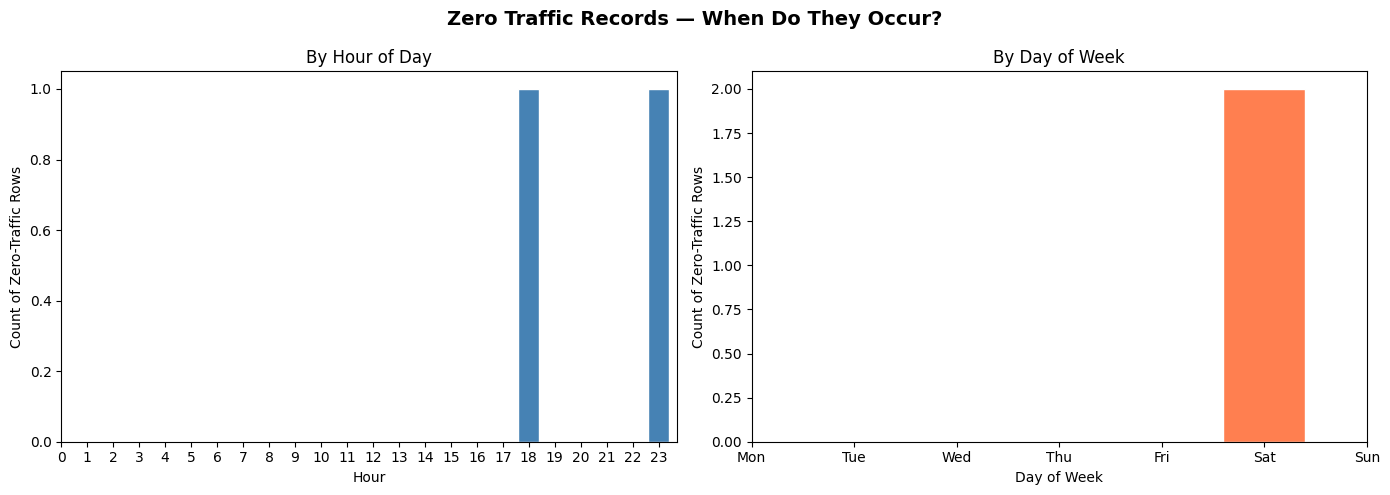

Figure saved ✅

  Zero-traffic rows during weekday peak hours (7–9am, 4–6pm): 0


In [ ]:
zero_mask = df[TARGET_COL] == 0
n_zeros   = zero_mask.sum()
pct_zeros = n_zeros / len(df) * 100

print(f"=== Zero Traffic Investigation ===")
print(f"  Rows with traffic_volume = 0 : {n_zeros:,} ({pct_zeros:.2f}% of dataset)")
print()

# ── Plot distribution of zeros by hour and day of week ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Zero Traffic Records — When Do They Occur?", fontsize=14, fontweight="bold")

zero_by_hour = df[zero_mask]["hour"].value_counts().sort_index()
axes[0].bar(zero_by_hour.index, zero_by_hour.values, color="steelblue", edgecolor="white")
axes[0].set_title("By Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count of Zero-Traffic Rows")
axes[0].set_xticks(range(0, 24))

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
zero_by_dow = df[zero_mask]["day_of_week"].value_counts().sort_index()
axes[1].bar(zero_by_dow.index, zero_by_dow.values, color="coral", edgecolor="white")
axes[1].set_title("By Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Count of Zero-Traffic Rows")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/zero_traffic_investigation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved ✅")

# ── Check zeros during peak hours on weekdays ─────────────────────────────────
peak_hours  = [7, 8, 9, 16, 17, 18]
peak_zeros  = df[zero_mask & df["hour"].isin(peak_hours) & (df["is_weekend"] == 0)]
print(f"\n  Zero-traffic rows during weekday peak hours (7–9am, 4–6pm): {len(peak_zeros)}")

#### 2.4.6 — Zero traffic decision

**Finding:** Only 2 rows have `traffic_volume = 0` (0.00% of dataset).  
Both occur on Saturday at hours 18 and 23 — plausible genuine low-traffic readings.  
Zero rows occur during weekday peak hours.  

**Decision:** Keep both rows. The count is too small to meaningfully bias any model,  
and the timing is consistent with genuine data, not sensor failure.